# Toxic Comment Classification: Statistical vs Neural Modeling Paradigms

**Course project:** Computational Linguistics - KU Leuven - 2025/2026  
**Author:** Teodora Taleska (Student ID: r1084475)  

This project addresses **multi-label toxic comment classification** using a subset of the **Jigsaw Toxic Comment** dataset. The objective is to compare two modeling paradigms under a consistent evaluation protocol:      
- **Statistical model:** bag-of-(uni,bi)gram features + one-vs-rest logistic regression  
- **Neural model:** fine-tuned pretrained transformer (**bert-base-uncased**) for multi-label classification  

Performance is evaluated primarily with **micro- and macro-averaged F1-score**, which are more appropriate than accuracy for this highly imbalanced setting. Beyond overall scores, the notebook includes error-pattern analysis via normalized label confusion matrices and qualitative probing to discuss interpretability and potential bias.

This notebook serves as the complete project report, with all methodology, results, and discussion presented inline in a structured, section-by-section format.


## 1. Imports

This section imports all required libraries and defines any global settings.

In [1]:
!pip install transformers accelerate datasets

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import classification_report, f1_score
from tqdm import tqdm

import torch
from transformers import AutoTokenizer
from datasets import Dataset
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import seaborn as sns
from sklearn.metrics import precision_score, recall_score

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

random.seed(42)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Data Loading & Exploration

### 2.1 Basic Data Inspection

The output below shows the first rows of the training dataset.

The training set contains **159,571 comments** and the test set contains **63,978 comments**, each with one text field and six binary toxicity labels. The `comment_text` column contains the raw comment, and the remaining columns indicate whether different types of toxic behavior (e.g., toxic, obscene, threat, insult, identity-based hate) are present (1) or not (0).


In [5]:
train_path = 'train.csv'
test_path = 'test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (159571, 8)
Test shape: (63978, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
for col in label_cols:
    print(col, sorted(train_df[col].unique().tolist()))

toxic [0, 1]
severe_toxic [0, 1]
obscene [0, 1]
threat [0, 1]
insult [0, 1]
identity_hate [0, 1]


### 2.2 Missing Values Check

We check whether there are missing values, especially in the `comment_text` column, since missing text would break vectorization and model training.

In [7]:
# print("Train data:\n", train_df.isna().sum())
# print("")
# print("Test data:\n", test_df.isna().sum())
# There are no missing values in the data. The code is commented, in order to not take space unnecessarily.

### 2.3 Label distribution

We compute how frequent each label is in the training data. This helps us understand class imbalance, which is important for choosing evaluation metrics (e.g., F1 rather than accuracy) and for interpreting model behaviour.

In [8]:
train_df[label_cols].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

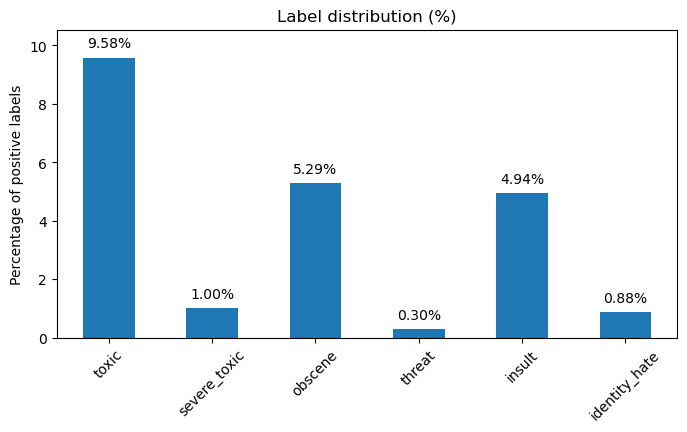

In [65]:
ax = (train_df[label_cols].mean() * 100).plot(kind="bar", figsize=(8,4)) # What percentage of all comments has this label = 1?
plt.ylabel("Percentage of positive labels")
plt.title("Label distribution (%)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.ylim(0, (train_df[label_cols].mean() * 100).max() * 1.1)
plt.xticks(rotation=45)

plt.show()

As we can see on the Figure representing the label distribution, the most frequent label among the comments is `toxic` with ~9.6% of all comments in the training set being toxic, which is not a big percentage. We have a highly imbalanced distribution, such that few categories are more frequent, whereas others, especially `threat`, `identity_hate`, and `severe_toxic` are very rare. With this we can conclude that there are around 89% of comments that are not labeled at all. This is important to be taken into account when training and evaluating the models, as it affects both model behaviour and the choice of appropriate metrics. In particular, it motivates the use of imbalance-aware metrics such as micro- and macro-averaged F1-score instead of accuracy, and it affects how models allocate capacity across frequent versus rare classes.

### 2.4 Multi-Label Characteristics (How Many Labels per Comment?)

The dataset is multi-label: a comment can have more than one positive label. Here we compute how many labels each comment has and how often multi-label combinations occur.

In [9]:
num_labels = train_df[label_cols].sum(axis=1)
(num_labels.value_counts(normalize=True).sort_index() * 100).round(2)

0    89.83
1     3.99
2     2.18
3     2.64
4     1.10
5     0.24
6     0.02
Name: proportion, dtype: float64

As we predicted before, the percentage of non-labeled comments is around 90%, meaning they are non-toxic. Among the toxic comments, most have only one or a few labels, while comments with many simultaneous toxicity labels are rare. This shows that the dataset is strongly skewed toward non-toxic content and that highly toxic comments are uncommon.

### 2.5 Label Co-Occurrence and Correlation

Some labels may sometimes appear together. We explore correlations to better understand which categories overlap and which are more distinct.


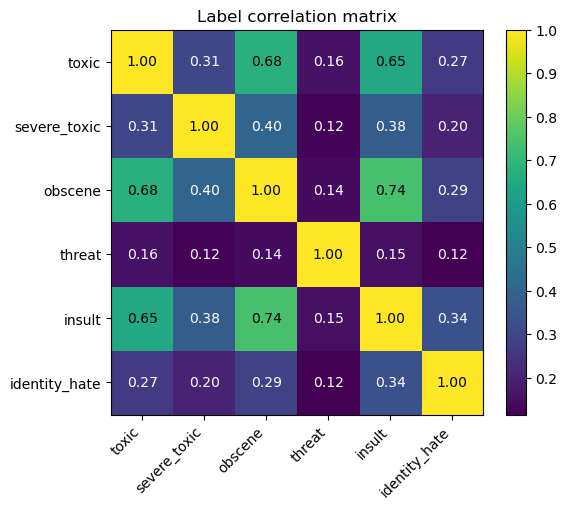

In [10]:
corr = train_df[label_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(label_cols)), label_cols, rotation=45, ha="right")
plt.yticks(range(len(label_cols)), label_cols)
plt.title("Label correlation matrix")

for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="white" if abs(corr.iloc[i, j]) < 0.6 else "black")

plt.show()

The heatmap shows the pairwise correlations between the different toxicity labels.

Some labels tend to co-occur frequently, especially `toxic` with `obscene` and `insult`, and `obscene` with `insult`, which have relatively high positive correlations. This suggests that many comments labeled as obscene or insulting are also labeled as generally toxic.

In contrast, the `threat` label shows low correlation with all other labels, indicating that threats are a more distinct and relatively independent category of toxic behavior.


### 2.6 Qualitative Exploration: Example Comments per Label

We inspect a few example comments for each label to understand what kinds of language patterns are associated with each toxicity category. This will later support both interpretability analysis and a linguistically informed discussion.

In [12]:
for label in label_cols:
    print(f"\n- Examples for label: {label.upper()}")
    sample = train_df[train_df[label] == 1].sample(2, random_state=42)["comment_text"].values
    for i, text in enumerate(sample, 1):
        print(f"\nExample {i}:\n{text[:500]}")
    print("_______________________________________________________________________________")


- Examples for label: TOXIC

Example 1:
Hi! 

I wanna rape you!

Example 2:
Terrorize 
I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threatening people you bastard.
_______________________________________________________________________________

- Examples for label: SEVERE_TOXIC

Example 1:
"

 WHAT  IN THE FUCK ARE YOU REFERRING TOO 

I HAVE NO IDEA WHAT THE PISS YOU'RE REFERRING TOO, OR WHY YOU BOTHERED TO WRITE ME.  LISTEN I'VE ADDED PLENTY TO THESE PAGE INCLUDING A ""SMASHING"" ARTICLE ON SMASHED GLADYS...BUT THAT REALLY ISNT ANY OF YOU BUSSINESS NOW IS IT.  IF SOMEBODY HAS A PROBLEM WITH ANYTHING THAT I WROTE THEM I ASSUME THEY CAN CONTACT ME THROUGH REGULAR MEANS WITHOUT YOU HAVING TO ""WIPE THEIR ASS"" FOR THEM.  IF I CAPITALIZE IT IS NOT MEANT NECCISARYLY AS AN INSULT, AND 

Example 2:
takes it up the arse.  takes it up the arse.  takes it up the arse.  takes i

## 3. Methodology and Evaluation Setup

We formulate the toxic comment detection as a **multi-label classification task** with six binary targets per comment (*toxic, severe_toxic, obscene, threat, insult, identity_hate*), allowing multiple labels to be active simultaneously. Two modeling paradigms are evaluated under the same protocol: a statistical model using bag-of-n-gram features with a one-vs-rest logistic regression classifier, and a neural model based on fine-tuning a pretrained transformer. The comparison focuses on differences in predictive performance, error structure, and interpretability.

Because the dataset is strongly imbalanced, we evaluate models using **micro- and macro-averaged F1-score** rather than accuracy. Micro-F1 reflects performance dominated by frequent labels, while macro-F1 weights all labels equally and is therefore sensitive to rare categories such as `threat` and `identity_hate`. Precision and recall are additionally reported to characterize error trade-offs; however, F1-score serves as the primary metric as it balances precision and recall into a single measure of classification quality. **Micro-averaged metrics are computed by aggregating true positives, false positives, and false negatives across all labels before computing the score, whereas macro-averaged metrics are computed by first calculating the metric independently for each label and then averaging across labels.**

The data are split into training, validation, and test sets using an 80/20 split for model development, with the held-out test set reserved exclusively for final evaluation. Both models are trained and evaluated on the same splits and using identical metrics to ensure comparability. For the statistical model, 10-fold cross-validation is used on the training data to estimate performance stability across different data partitions and to quantify variance.


In [9]:
# train/validation split 
train_idx, val_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=42
)

train_split = train_df.loc[train_idx]
val_split = train_df.loc[val_idx]

In [38]:
# helper functions for the evaluation later (in Section 6)

def label_confusion_matrix(y_true, y_pred, label_names):
    n = len(label_names)
    mat = np.zeros((n, n), dtype=int)

    for yt, yp in zip(y_true, y_pred):
        true_indices = np.where(yt == 1)[0]
        pred_indices = np.where(yp == 1)[0]

        for i in true_indices:
            for j in pred_indices:
                mat[i, j] += 1

    return mat

def normalize_rows(mat):
    row_sums = mat.sum(axis=1, keepdims=True)
    return np.divide(mat, row_sums, where=row_sums!=0)

def plot_side_by_side(mat1, mat2, label_names, titles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    sns.heatmap(mat1,
                xticklabels=label_names,
                yticklabels=label_names,
                cmap="viridis",
                annot=True, fmt=".2f",
                ax=axes[0])
    axes[0].set_title(titles[0])
    axes[0].set_xlabel("Predicted label")
    axes[0].set_ylabel("True label")
    axes[0].tick_params(axis='x', rotation=30)

    sns.heatmap(mat2,
                xticklabels=label_names,
                yticklabels=label_names,
                cmap="viridis",
                annot=True, fmt=".2f",
                ax=axes[1])
    axes[1].set_title(titles[1])
    axes[1].set_xlabel("Predicted label")
    axes[1].set_ylabel("")
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    
    
def predict_text_stat(text):
    X = vectorizer.transform([text])
    probs = clf.predict_proba(X)
    print("Statistical model probabilities:", probs)
    return (probs > 0.5).astype(int)


def predict_text_bert(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits)
    print("BERT probabilities:", probs.cpu().numpy())
    return (probs.cpu().numpy() > 0.5).astype(int)

def compare_models(text):
    print("_"*80)
    print("Text:", text)
    print()

    stat_pred = predict_text_stat(text)
    bert_pred = predict_text_bert(text)

    print("\nPredicted labels:")
    print("Statistical:", dict(zip(label_cols, stat_pred[0])))
    print("BERT: ", dict(zip(label_cols, bert_pred[0])))

    diff = stat_pred[0] != bert_pred[0]
    if diff.any():
        print("\nDifferences:")
        for i, d in enumerate(diff):
            if d:
                print(f" - {label_cols[i]}: Stat={stat_pred[0][i]}, BERT={bert_pred[0][i]}")
    else:
        print("\nNo differences between models.")


## 4. Statistical Model: Logistic Regression

In this section, we implement the statistical model introduced in Section 3. Following the approach used in the practical sessions, we represent each comment as a vector of surface lexical features and train a linear classifier to predict toxicity labels. This model serves as a transparent baseline that allows direct inspection of learned feature weights.

### 4.1 Text Vectorization

As discussed in Section 3, we represent each comment using a bag-of-n-grams representation. We use scikit-learn’s `CountVectorizer` to extract unigram and bigram features from the raw text. This representation encodes each document as a vector of word and short phrase counts, without taking word order or syntactic structure into account.

We limit the feature space to the 15,000 most frequent n-grams in the training data (`max_features = 15000`). This limits the dimensionality of the representation, reduces sparsity and noise from extremely rare features, and keeps the model computationally tractable and interpretable. Given the large size of the dataset (over 150,000 training comments), this value provides a balance between expressive power and simplicity, while following the feature selection strategy demonstrated in the course practicals.



In [11]:
X_train = train_split["comment_text"]
y_train = train_split[label_cols]
X_val = val_split["comment_text"]
y_val = val_split[label_cols]

# Bag-of-n-grams vectorization (unigrams + bigrams)
vectorizer = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=15000,
    lowercase=True
)

X_train_vec = vectorizer.fit_transform(X_train) # the actual feature transformation
X_val_vec = vectorizer.transform(X_val)

print("Training feature matrix shape:", X_train_vec.shape)
print("Validation feature matrix shape:", X_val_vec.shape)


Training feature matrix shape: (127656, 15000)
Validation feature matrix shape: (31915, 15000)


### 4.2 Model Training

We train the LogReg classifier using a **one-vs-rest** strategy, where a separate binary classifier is learned for each toxicity label. Logistic regression is a linear model that estimates the contribution of each feature to the probability of a label being present.

#### 4.2.1 Cross-Validation

Before training the final statistical model, we perform k-fold cross-validation (CV) using k=10, because it is usually used as a good practice, on the training data to obtain a more robust estimate of model performance and verify that the chosen configuration generalizes well.


In [16]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_micro = []
cv_macro = []

cv_micro_p = []
cv_micro_r = []
cv_macro_p = []
cv_macro_r = []

for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train_vec), total=10, desc="Cross-validation")):
    X_tr, X_va = X_train_vec[train_idx], X_train_vec[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    clf_cv = OneVsRestClassifier(
        LogisticRegression(
            max_iter=1500,
            solver="lbfgs",
            n_jobs=-1
        )
    )
    clf_cv.fit(X_tr, y_tr)
    y_pred = clf_cv.predict(X_va)

    micro_f1 = f1_score(y_va, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_va, y_pred, average="macro", zero_division=0)

    micro_p = precision_score(y_va, y_pred, average="micro", zero_division=0)
    micro_r = recall_score(y_va, y_pred, average="micro", zero_division=0)

    macro_p = precision_score(y_va, y_pred, average="macro", zero_division=0)
    macro_r = recall_score(y_va, y_pred, average="macro", zero_division=0)

    cv_micro.append(micro_f1)
    cv_macro.append(macro_f1)

    cv_micro_p.append(micro_p)
    cv_micro_r.append(micro_r)
    cv_macro_p.append(macro_p)
    cv_macro_r.append(macro_r)

cv_micro = np.array(cv_micro)
cv_macro = np.array(cv_macro)

cv_micro_p = np.array(cv_micro_p)
cv_micro_r = np.array(cv_micro_r)
cv_macro_p = np.array(cv_macro_p)
cv_macro_r = np.array(cv_macro_r)

Cross-validation: 100%|██████████| 10/10 [13:14<00:00, 79.40s/it]


In [17]:
print("\nCross-validation results:")
print(f"Micro-F1: mean = {cv_micro.mean():.4f}, std = {cv_micro.std():.4f}, SE = {cv_micro.std()/np.sqrt(len(cv_micro)):.4f}")
print(f"Macro-F1: mean = {cv_macro.mean():.4f}, std = {cv_macro.std():.4f}, SE = {cv_macro.std()/np.sqrt(len(cv_macro)):.4f}")

print(f"Micro-Precision (avg over folds): {cv_micro_p.mean():.4f}")
print(f"Micro-Recall (avg over folds): {cv_micro_r.mean():.4f}")

print(f"Macro-Precision (avg over folds): {cv_macro_p.mean():.4f}")
print(f"Macro-Recall (avg over folds): {cv_macro_r.mean():.4f}")


Cross-validation results:
Micro-F1: mean = 0.6850, std = 0.0086, SE = 0.0027
Macro-F1: mean = 0.5323, std = 0.0151, SE = 0.0048
Micro-Precision (avg over folds): 0.7804
Micro-Recall (avg over folds): 0.6104
Macro-Precision (avg over folds): 0.6361
Macro-Recall (avg over folds): 0.4631


In [18]:
clf = OneVsRestClassifier(
      LogisticRegression(
          max_iter=1500,
          solver="lbfgs",
          n_jobs=-1
      )
    )
clf.fit(X_train_vec, y_train)

print("Model training completed.")

Model training completed.


### 4.3 Evaluation on Test Set

We evaluate the statistical model on the aforementioned evaluation metrics.

In [21]:
X_test_vec = vectorizer.transform(test_df["comment_text"])
y_test = test_df[label_cols]

y_test_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_test_pred, target_names=label_cols, zero_division=0))

               precision    recall  f1-score   support

        toxic       0.58      0.72      0.64      6090
 severe_toxic       0.38      0.39      0.38       367
      obscene       0.68      0.63      0.65      3691
       threat       0.31      0.34      0.33       211
       insult       0.66      0.50      0.57      3427
identity_hate       0.40      0.23      0.29       712

    micro avg       0.60      0.60      0.60     14498
    macro avg       0.50      0.47      0.48     14498
 weighted avg       0.61      0.60      0.60     14498
  samples avg       0.06      0.06      0.06     14498



### 4.4 Interpretability

A key advantage of the statistical model is its interpretability. Because logistic regression is a linear classifier, each feature is associated with a learned weight that reflects its contribution to a particular label. By inspecting the highest-weighted features, we can identify which words or phrases are most strongly associated with different types of toxicity.

In [23]:
feature_names = np.array(vectorizer.get_feature_names_out())

def show_top_features(classifier, label_name, top_n=10):
    coef = classifier.coef_.ravel()
    top_positive = np.argsort(coef)[-top_n:]
    top_negative = np.argsort(coef)[:top_n]

    print(f"\nTop positive features for label '{label_name}':")
    for i in tqdm(reversed(top_positive), total=len(top_positive), desc="Positive features"):
        print(f"{feature_names[i]} ({coef[i]:.3f})")

    print(f"\nTop negative features for label '{label_name}':")
    for i in tqdm(top_negative, total=len(top_negative), desc="Negative features"):
        print(f"{feature_names[i]} ({coef[i]:.3f})")

In [24]:
# we inspect one label as example
label_idx = label_cols.index('toxic')
show_top_features(clf.estimators_[label_idx], 'toxic')


Top positive features for label 'toxic':


Positive features: 100%|██████████| 10/10 [00:00<?, ?it/s]


fuck (6.231)
fucking (5.873)
idiot (4.991)
faggot (4.608)
shit (4.549)
bitch (4.502)
fucked (4.266)
stupid (4.238)
suck (4.178)
penis (4.123)

Top negative features for label 'toxic':


Negative features: 100%|██████████| 10/10 [00:00<?, ?it/s]

supertr0ll (-2.533)
twat twat (-2.209)
adam (-2.097)
wikipedia administrators (-2.062)
think there (-1.987)
season (-1.970)
like an (-1.917)
rose (-1.898)
people don (-1.889)
time for (-1.883)


In [48]:
label_idx = label_cols.index('identity_hate')
show_top_features(clf.estimators_[label_idx], 'identity_hate')


Top positive features for label 'identity_hate':


Positive features: 100%|██████████| 10/10 [00:00<00:00, 3333.31it/s]


nigger (4.654)
niggers (4.074)
homosexual (3.845)
homo (2.803)
gay (2.671)
jew (2.378)
niggas (2.102)
muslim (2.002)
disgusting (1.757)
fucked (1.742)

Top negative features for label 'identity_hate':


Negative features: 100%|██████████| 10/10 [00:00<00:00, 3330.93it/s]

nigger nigger (-4.646)
nhrhs2010 (-1.741)
faggots faggots (-1.714)
am gay (-1.646)
category (-1.642)
gay im (-1.639)
im gay (-1.620)
ur (-1.567)
fucking asshole (-1.498)
you hate (-1.477)


## 5. Neural Model: BERT Fine-Tuning

In this section, we fine-tune a pretrained transformer-based language model. Following the methodology of Practical Session 5, we use Hugging Face’s transformers library to load a pretrained model, tokenize the input, and fine-tune the model using a supervised classification objective.

Unlike the statistical model, which relies on explicitly defined lexical features, the transformer model learns contextual representations of text and can in principle capture longer-range dependencies and more subtle semantic patterns.

### 5.1 Tokenization and Input Preparation

We use a pretrained BERT tokenizer to convert raw comments into token IDs and attention masks. These representations serve as input to the transformer model.

In [25]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, clean_up_tokenization_spaces=True)

In [26]:
# to convert the pandas DataFrame into Hugging Face datasets
train_df_nn = train_split
val_df_nn = val_split

train_hf = Dataset.from_pandas(train_df_nn[["comment_text"] + label_cols].reset_index(drop=True))
val_hf   = Dataset.from_pandas(val_df_nn[["comment_text"] + label_cols].reset_index(drop=True))
test_hf  = Dataset.from_pandas(test_df[["comment_text"] + label_cols].reset_index(drop=True))

In [27]:
# we combine the 6 binary label columns into ONE "labels" vector because the model requires it
def add_labels(example):
    example["labels"] = [
        float(example["toxic"]),
        float(example["severe_toxic"]),
        float(example["obscene"]),
        float(example["threat"]),
        float(example["insult"]),
        float(example["identity_hate"]),
    ]
    return example


train_hf = train_hf.map(add_labels)
val_hf   = val_hf.map(add_labels)
test_hf  = test_hf.map(add_labels)

# we remove the old individual label columns
train_hf = train_hf.remove_columns(label_cols)
val_hf   = val_hf.remove_columns(label_cols)
test_hf  = test_hf.remove_columns(label_cols)

def tokenize(batch):
    return tokenizer(batch["comment_text"], truncation=True, padding=True, max_length=128)

train_hf = train_hf.map(tokenize, batched=True)
val_hf   = val_hf.map(tokenize, batched=True)
test_hf  = test_hf.map(tokenize, batched=True)

# set torch format INCLUDING "labels"
train_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

Map:   0%|          | 0/63978 [00:00<?, ? examples/s]

Map:   0%|          | 0/127656 [00:00<?, ? examples/s]

Map:   0%|          | 0/31915 [00:00<?, ? examples/s]

Map:   0%|          | 0/63978 [00:00<?, ? examples/s]

### 5.2 Model Training

We fine-tune the pretrained BERT model by adding a classification head and training it to predict the six toxicity labels using **binary cross-entropy loss**.

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    problem_type="multi_label_classification"
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions
    preds = (logits > 0).astype(int)  # threshold at 0 logits == 0.5 prob after sigmoid

    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "micro_precision": precision_score(labels, preds, average="micro", zero_division=0), 
        "micro_recall": recall_score(labels, preds, average="micro", zero_division=0),
    }

In order to fine-tune the transformer model, we need to set a lot of hyperparameters. These hyperparameters will be provided as training arguments and are motivated from the practical.

In [31]:
training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    learning_rate=5e-5,
    fp16=torch.cuda.is_available(),
    eval_strategy="steps",
    eval_steps=1000,
    report_to="none"
)

In [32]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

In [33]:
trainer.train()

Step,Training Loss,Validation Loss,Micro F1,Macro F1,Micro Precision,Micro Recall
1000,0.062600,0.051348,0.737751,0.387340,0.779421,0.700311
2000,0.050800,0.050040,0.724220,0.418403,0.823487,0.646310
3000,0.052200,0.047586,0.741275,0.390497,0.810330,0.683065
4000,0.046000,0.046725,0.744339,0.390202,0.834945,0.671473
5000,0.045900,0.044053,0.760706,0.397660,0.788826,0.734521
6000,0.044600,0.046103,0.726905,0.414619,0.848651,0.635708
7000,0.038300,0.043856,0.745185,0.438898,0.843761,0.667232
8000,0.042700,0.041928,0.760711,0.450826,0.834318,0.699039
9000,0.033600,0.043581,0.766946,0.576667,0.831407,0.711761
10000,0.036800,0.041878,0.779223,0.615557,0.816254,0.745406


TrainOutput(global_step=15958, training_loss=0.04389364157781996, metrics={'train_runtime': 2770.8268, 'train_samples_per_second': 92.143, 'train_steps_per_second': 5.759, 'total_flos': 1.6794455582416896e+16, 'train_loss': 0.04389364157781996, 'epoch': 2.0})

### 5.3 Evaluation on the Test Set

We evaluate the fine-tuned BERT model on the held-out test set using the same micro- and macro-averaged F1 metrics as for the statistical model. This ensures that performance comparisons between the two modelling paradigms are fair and directly comparable.

We use the Trainer’s built-in evaluation function, which computes the metrics defined in `compute_metrics` and provides a standardized evaluation of the model on the test data.

In [40]:
test_metrics = trainer.evaluate(test_hf)

print("BERT test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

BERT test metrics:
eval_loss: 0.0661
eval_micro_f1: 0.6858
eval_macro_f1: 0.6129
eval_micro_precision: 0.6015
eval_micro_recall: 0.7976
eval_runtime: 84.2032
eval_samples_per_second: 759.8050
eval_steps_per_second: 23.7520
epoch: 2.0000


### 5.4 Interpretability

To explore the behavior of the neural model, we inspect example predictions and compare them with the statistical model, focusing on cases where contextual information appears to help or where both models fail.

In [55]:
pairs = [
    "You are an idiot and a disgusting person.",
    "I will kill you.",
    "I hate Muslims.",
    "I hate Christians.",
]

for p in pairs:
    print(p, predict_text_bert(p), "\n")

BERT probabilities: [[0.9877587  0.0462919  0.6620321  0.01020905 0.913368   0.07864238]]
You are an idiot and a disgusting person. [[1 0 1 0 1 0]] 

BERT probabilities: [[0.9781772  0.15443976 0.3276683  0.8198933  0.3233801  0.05953749]]
I will kill you. [[1 0 0 1 0 0]] 

BERT probabilities: [[0.90632194 0.0269123  0.12951279 0.04681203 0.21917035 0.47973216]]
I hate Muslims. [[1 0 0 0 0 0]] 

BERT probabilities: [[0.91398406 0.0173091  0.06030764 0.06465349 0.16158468 0.25645936]]
I hate Christians. [[1 0 0 0 0 0]] 



## 6. Comparative Analysis and Discussion

Here we compare the two modeling paradigms with respect to predictive performance, error patterns, interpretability, and potential bias. The goal is not only to determine which model performs better, but also to understand how and why their behavior differs.

### 6.1 Comparative Experiment
Both models are evaluated on the same held-out test set using identical metrics and thresholds. In addition to micro- and macro-averaged F1-scores, we analyze label-wise error patterns using normalized label confusion matrices and inspect selected qualitative examples to probe model behavior.




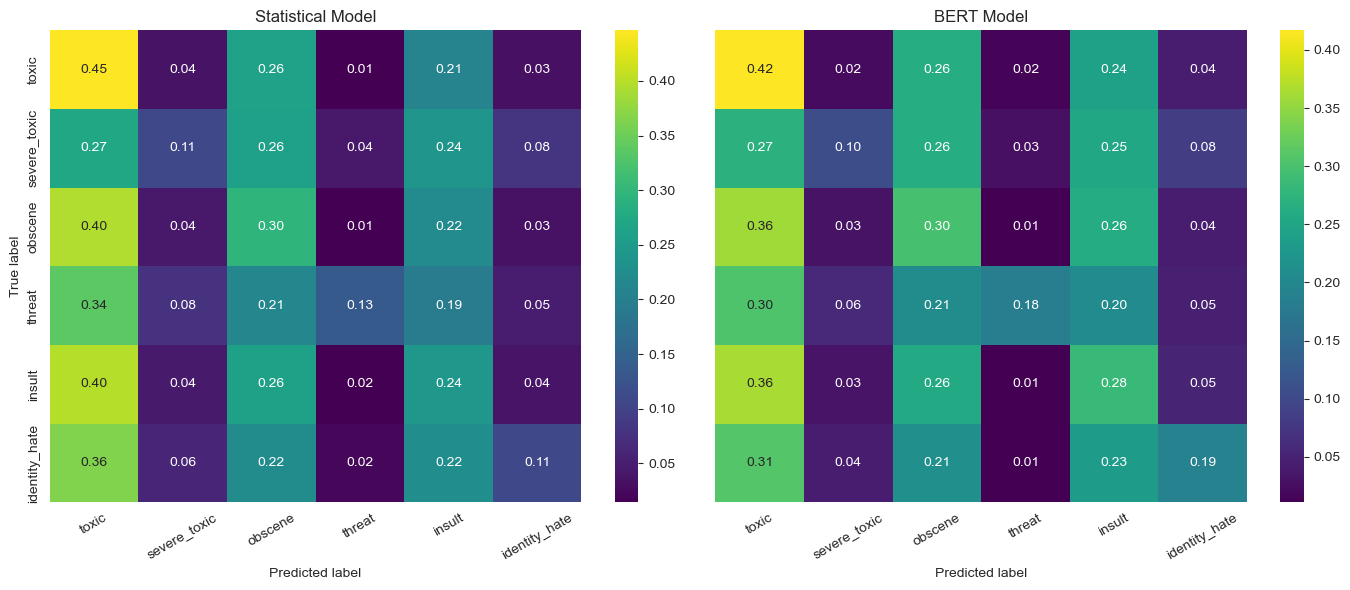

In [43]:
# LogReg
y_stat_true = y_test.values
y_stat_pred = clf.predict(X_test_vec)
stat_mat = label_confusion_matrix(y_stat_true, y_stat_pred, label_cols)
stat_mat_norm = normalize_rows(stat_mat)

# BERT 
pred = trainer.predict(test_hf)

y_bert_true = test_df[label_cols].values
y_bert_pred = (pred.predictions > 0).astype(int)
bert_mat = label_confusion_matrix(y_bert_true, y_bert_pred, label_cols)
bert_mat_norm = normalize_rows(bert_mat)

plot_side_by_side(
    stat_mat_norm,
    bert_mat_norm,
    label_cols,
    ["Statistical Model", "BERT Model"]
)

In [53]:
# for reference: [ toxic, severe_toxic, obscene, threat, insult, identity_hate ]
compare_models("You are an idiot and a disgusting person.")
compare_models("I will kill you.")
compare_models("You are not very smart, but I understand your point.")
compare_models("I hate Muslims.")
compare_models("I hate women.")
compare_models("You are so fucking beautiful Amanda!!")
compare_models("Vladimir is super ugly influencer.")

________________________________________________________________________________
Text: You are an idiot and a disgusting person.

Statistical model probabilities: [[0.99670935 0.02702283 0.3822462  0.00508279 0.96857163 0.18728781]]
BERT probabilities: [[0.9877587  0.0462919  0.6620321  0.01020905 0.913368   0.07864238]]

Predicted labels:
Statistical: {'toxic': 1, 'severe_toxic': 0, 'obscene': 0, 'threat': 0, 'insult': 1, 'identity_hate': 0}
BERT:  {'toxic': 1, 'severe_toxic': 0, 'obscene': 1, 'threat': 0, 'insult': 1, 'identity_hate': 0}

Differences:
 - obscene: Stat=0, BERT=1
________________________________________________________________________________
Text: I will kill you.

Statistical model probabilities: [[0.82970354 0.03200143 0.03589164 0.61722394 0.03287088 0.01239953]]
BERT probabilities: [[0.9781772  0.15443976 0.3276683  0.8198933  0.3233801  0.05953749]]

Predicted labels:
Statistical: {'toxic': 1, 'severe_toxic': 0, 'obscene': 0, 'threat': 1, 'insult': 0, 'identity_h

### 6.2 Performance Comparison

We compare the two models using micro- and macro-averaged F1-score, precision, and recall, and analyze their errors using the normalized label confusion matrices shown in Figure 6.1. 

On the test set, the statistical model achieves a **micro-F1 of 0.603** and a **macro-F1 of 0.477**, whereas the transformer model reaches a higher **micro-F1 of 0.686** and a notably higher **macro-F1 of 0.613**. The similar micro-F1 scores indicate that both models perform reasonably well on frequent labels such as `toxic`, `obscene`, and `insult`. However, the large gap in macro-F1 reveals a clear difference in how the models handle rare labels. The transformer model is much more effective at detecting rare categories, while the statistical model struggles to generalize beyond common lexical patterns.

This difference is further reflected in recall. The statistical model has a **micro-recall of 0.604**, while the transformer achieves a much higher **micro-recall of 0.798**, meaning that the neural model detects a considerably larger fraction of all toxic instances. For rare categories, the difference is especially noticeable: the statistical model recalls only **23% of `identity_hate`** and **34% of `threats`**, indicating that many true instances of these labels are missed. The transformer model improves recall significantly, although this increased sensitivity sometimes comes with slightly lower precision, reflecting a trade-off between detecting more harmful content and avoiding false positives.

The normalized confusion matrices in Figure 6.1 help us see how these metric differences arise. Each row in the matrix represents a true label, and each cell shows the proportion of instances of that true label predicted as another category. Diagonal values correspond to correct predictions, while off-diagonal mass indicates systematic misclassifications. The statistical model has strong off-diagonal mass toward the generic `toxic` category, meaning that many true `identity_hate` and `threat` instances are predicted simply as `toxic`. This suggests that the statistical model captures general negativity but lacks the semantic resolution needed to distinguish different types of harmful behavior. This behavior is consistent with the dataset structure, where rare labels often co-occur with `toxic` and share lexical cues, making them difficult to separate using surface features alone (Section 2.5).

In contrast, the transformer model shows a stronger diagonal structure, indicating better alignment between true and predicted labels. Although some confusion remains between closely related categories such as `obscene` and `insult`, the neural model preserves distinctions better for semantically defined labels like `threat` and `identity_hate`. This suggests that contextual representation learning enables the model to move beyond lexical triggers and incorporate information about intent and meaning.

Overall, the statistical model performs well on frequent and lexically explicit patterns but systematically collapses rare or subtle categories into general toxicity. The transformer model achieves higher overall performance by improving recall and specificity on rare labels, at the cost of increased model complexity and reduced interpretability.


### 6.3 Interpretability and Semantic Sensitivity

The two models differ not only in performance but also in how their decisions can be understood and analyzed. The logistic regression model is directly interpretable through its feature weights. The highest-weighted features for the `toxic` label are explicit swear words such as “fuck”, “idiot”, and “shit”, showing that the model relies heavily on lexical cues. This makes its behavior easy to explain, but also limits its ability to detect toxicity that is expressed implicitly. For example, it does not classify “I hate women.” or “Vladimir is super ugly influencer.” as toxic, because these sentences lack strong lexical triggers.

The neural model shows a different behavior. Although it is less transparent, qualitative probes indicate that it is more sensitive to meaning and intent. It correctly classifies “I hate women.” and “Vladimir is super ugly influencer.” as toxic, while the statistical model does not. Both models correctly detect explicit threats (“I will kill you.”) and avoid flagging mild criticism (“You are not very smart, but I understand your point.”). The probe also reveals subtle sensitivity differences. For the pattern “I hate X”, the model does not predict `identity_hate` for any tested group, but assigns higher internal confidence when X refers to religious groups than when it refers to gender groups. This suggests a soft form of bias that affects model confidence rather than final decisions, likely reflecting patterns in the training or pretraining data.

Hence, we can conclude that the statistical model is transparent but semantically shallow, while the transformer model is semantically richer but harder to explain and potentially encodes subtle biases. 


## 7. Conclusion

As a conclusion, this comparison highlights a clear trade-off between performance and interpretability in toxic comment classification. The transformer-based model achieves higher overall performance, particularly on rare and semantically defined labels such as *threat* and *identity_hate*, as reflected in its stronger macro-averaged F1-score and improved recall for rare categories. This suggests that contextual representations allow the model to better distinguish between different types of harmful content. In contrast, the statistical model performs competitively on frequent and lexically explicit categories and offers a high degree of transparency through its interpretable feature weights. However, it struggles with implicit or context-dependent toxicity and often treats different types of harmful content as the same general toxicity category.

The qualitative probes further show that while the neural model is more sensitive to meaning and intent, it also shows subtle differences in confidence across references to different social groups, even when final predictions remain unchanged. This underlines the importance of complementing quantitative metrics with qualitative analysis when evaluating models for socially sensitive tasks.
